# Explore here

It's recommended to use this notebook for exploration purposes.

In [37]:
import os
from bs4 import BeautifulSoup
import requests
import time
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns

url = "https://ycharts.com/companies/TSLA/revenues"
html_data = requests.get(url, time.sleep(10)).text

if "403 ERROR" in html_data:
    headers = {'User-Agent': 'Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/58.0.3029.110 Safari/537.3'}
    html_data = requests.get(url, headers=headers)
    time.sleep(5)
    html_data = html_data.text

html_data



'\n\n\n\n\n\n\n<!doctype html>\n<html lang="en" ng-jq>\n    <head>\n        <title>\n        Tesla Revenue (Quarterly) Analysis | YCharts\n        </title>\n\n        <meta name="viewport" content="width=device-width, initial-scale=1.0" />\n<!-- This code allows us to correctly display the page on mobile devices -->\n<script defer>\n    var viewport = document.querySelector(\'meta[name=viewport]\');\n    if (viewport) {\n        var minWidth = 700;\n        if (screen.width < minWidth) {\n            document.head.removeChild(viewport);\n            var newViewport = document.createElement(\'meta\');\n            newViewport.setAttribute(\'name\', \'viewport\');\n            newViewport.setAttribute(\'content\', \'width=\' + minWidth);\n            document.head.appendChild(newViewport);\n        }\n    }\n</script>\n\n\n        \n        <script>\n    if (navigator.userAgent.indexOf(\'Trident\') !== -1 || navigator.userAgent.indexOf(\'MSIE\') !== -1) {\n        window.onload=function(

In [38]:
soup = BeautifulSoup(html_data, "html.parser")
soup


<!DOCTYPE html>

<html lang="en" ng-jq="">
<head>
<title>
        Tesla Revenue (Quarterly) Analysis | YCharts
        </title>
<meta content="width=device-width, initial-scale=1.0" name="viewport"/>
<!-- This code allows us to correctly display the page on mobile devices -->
<script defer="">
    var viewport = document.querySelector('meta[name=viewport]');
    if (viewport) {
        var minWidth = 700;
        if (screen.width < minWidth) {
            document.head.removeChild(viewport);
            var newViewport = document.createElement('meta');
            newViewport.setAttribute('name', 'viewport');
            newViewport.setAttribute('content', 'width=' + minWidth);
            document.head.appendChild(newViewport);
        }
    }
</script>
<script>
    if (navigator.userAgent.indexOf('Trident') !== -1 || navigator.userAgent.indexOf('MSIE') !== -1) {
        window.onload=function() {
            var ie_banner = document.createElement('div');
            ie_banner.innerT

In [39]:
tables = soup.find_all("table")
tables

[<table class="table">
 <thead>
 <tr>
 <th>Date</th>
 <th class="text-right">Value</th>
 </tr>
 </thead>
 <tbody>
 <tr>
 <td>December 31, 2023</td>
 <td class="text-right">
                             
                                 25.17B
                             
                         </td>
 </tr>
 <tr>
 <td>September 30, 2023</td>
 <td class="text-right">
                             
                                 23.35B
                             
                         </td>
 </tr>
 <tr>
 <td>June 30, 2023</td>
 <td class="text-right">
                             
                                 24.93B
                             
                         </td>
 </tr>
 <tr>
 <td>March 31, 2023</td>
 <td class="text-right">
                             
                                 23.33B
                             
                         </td>
 </tr>
 <tr>
 <td>December 31, 2022</td>
 <td class="text-right">
                             
               

In [42]:
for index, table in enumerate(tables):
    if ("Date" in str(table)):
        table_index = index
        break
    

In [ ]:
import pandas as pd

tesla_df = pd.DataFrame(columns=["Date", "Revenue"])
for row in tables[table_index].find_all("tr"):
    col = row.find_all("td")
    if (col != []):
        Date = col[0].text
        Revenue = col[1].text.strip().replace("B","")
        tesla_df = pd.concat([tesla_df, pd.DataFrame({
            "Date": Date,
            "Revenue": Revenue
        }, index=[0])], ignore_index=True)

tesla_df.head()

In [ ]:
import sqlite3

conn = sqlite3.connect('tesla.db')
c = conn.cursor()

c.execute("CREATE TABLE tesla_revenue (date TEXT, revenue REAL)")
conn.commit()

tesla_df.to_sql('tesla_revenue', conn, if_existes='replace', index = False)

In [ ]:
c.execute('SELECT * FROM tesla_revenue').fetchall()

Text(0.5, 1.0, 'Date and revenue')

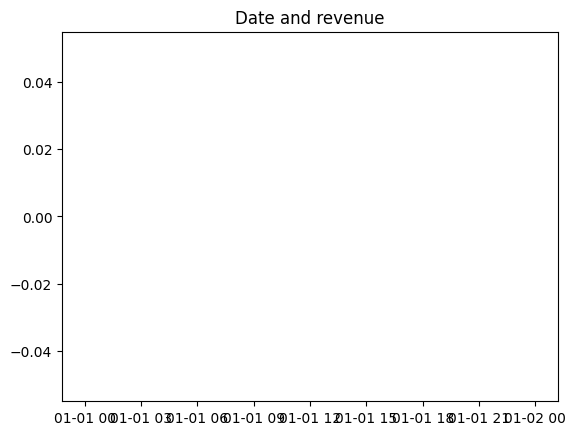

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

tesla_df["Date"] = pd.to_datetime(tesla_df["Date"])

plt.plot(tesla_df["Date"], tesla_df["Revenue"])
plt.title("Date and revenue")


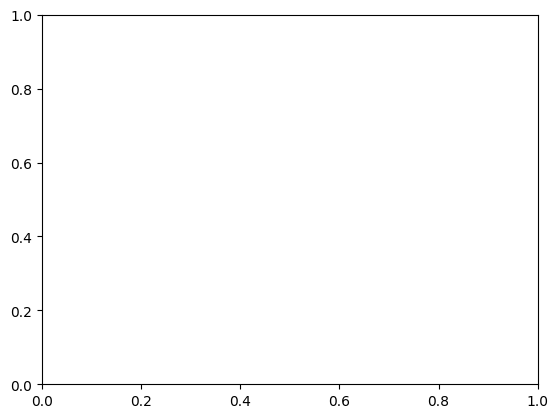

In [ ]:
#para hacer grafico anual debemos hacer una columna distinta

tesla_revenue_anual = tesla_df.groupby(tesla_df["Date"].dt.year).sum()
sns.barplot(x=tesla_revenue_anual.index, y=tesla_revenue_anual.values)
plt.show()